# 1.3. Introducción al Modelado y Simulación
## Tarea: Creación de un Modelo Conceptual

Sistema elegido: **plataforma de recomendación de películas**, usando como base de
datos real el dataset `movies.csv` (TMDB 5000 Movies), que contiene 4803 películas
con atributos como género, reparto (`cast`), equipo de producción (`crew`),
director, sinopsis (`overview`), palabras clave (`keywords`), calificación
promedio (`vote_average`) y número de votos (`vote_count`).

Un modelo conceptual no busca programar el sistema completo, sino **identificar
sus partes clave y cómo se relacionan entre sí**, antes de pasar a la
implementación técnica.

### 1. Elección del sistema

**Sistema de la vida real:** una plataforma de streaming (tipo Netflix/Prime Video)
que le recomienda películas a un usuario a partir del catálogo disponible y de su
historial de interacción.

Es un sistema simple pero completo: tiene datos de entrada (el catálogo, en
`movies.csv`), un usuario que interactúa con el sistema, un proceso que
transforma esos datos en una salida (una lista de recomendaciones), y una
retroalimentación (el usuario califica o ignora lo recomendado, lo cual
vuelve a alimentar al sistema).

### 2. Componentes principales

| Componente | Descripción | Columnas de `movies.csv` relacionadas |
|---|---|---|
| **Catálogo de películas** | Repositorio central con la información de cada película | `title`, `genres`, `overview`, `keywords`, `release_date`, `runtime` |
| **Perfil de contenido** | Atributos que describen "de qué trata" cada película | `genres`, `keywords`, `cast`, `crew`, `director`, `overview` |
| **Popularidad / calidad** | Señal agregada de qué tan bien recibida es una película | `vote_average`, `vote_count`, `popularity` |
| **Usuario** | Persona que ve películas y genera preferencias | (externo al csv: historial de reproducción) |
| **Motor de recomendación** | Algoritmo que compara perfiles de contenido y sugiere películas similares | procesa las columnas de arriba |
| **Interfaz / Plataforma** | Medio por el cual el usuario ve el catálogo y recibe recomendaciones | (externo al csv) |

A continuación exploramos el catálogo real para justificar estos componentes.

In [1]:
import pandas as pd

df = pd.read_csv("movies.csv")
print("Películas en el catálogo:", df.shape[0])
print("Columnas:", df.shape[1])
df[["title", "genres", "director", "vote_average", "vote_count", "popularity"]].head(5)

Películas en el catálogo: 4803
Columnas: 24


,title,genres,director,vote_average,vote_count,popularity
0,Avatar,Action Adventure Fantasy Science Fiction,James Cameron,7.2,11800,150.437577
1,Pirates of the Caribbean: At World's End,Adventure Fantasy Action,Gore Verbinski,6.9,4500,139.082615
2,Spectre,Action Adventure Crime,Sam Mendes,6.3,4466,107.376788
3,The Dark Knight Rises,Action Crime Drama Thriller,Christopher Nolan,7.6,9106,112.312950
4,John Carter,Action Adventure Science Fiction,Andrew Stanton,6.1,2124,43.926995


In [2]:
# El "perfil de contenido" de una película: lo que el motor de recomendación compara
ejemplo = df.loc[df["title"] == "Avatar", ["title", "genres", "keywords", "director", "cast"]]
ejemplo

,title,genres,keywords,director,cast
0,Avatar,Action Adventure Fantasy Science Fiction,culture clash future space war space colony so...,James Cameron,Sam Worthington Zoe Saldana Sigourney Weaver S...


In [3]:
# La señal de "popularidad / calidad" que complementa el contenido
top_calificadas = df.sort_values("vote_average", ascending=False)
top_calificadas = top_calificadas[top_calificadas["vote_count"] > 1000]
top_calificadas[["title", "vote_average", "vote_count", "popularity"]].head(10)

,title,vote_average,vote_count,popularity
1881,The Shawshank Redemption,8.5,8205,136.747729
3337,The Godfather,8.4,5893,143.659698
2294,Spirited Away,8.3,3840,118.968562
3865,Whiplash,8.3,4254,192.528841
2731,The Godfather: Part II,8.3,3338,105.792936
3232,Pulp Fiction,8.3,8428,121.463076
662,Fight Club,8.3,9413,146.757391
1818,Schindler's List,8.3,4329,104.469351
1990,The Empire Strikes Back,8.2,5879,78.517830
65,The Dark Knight,8.2,12002,187.322927


### 3. Interacciones entre los componentes

1. El **Catálogo de películas** alimenta al **Motor de recomendación** con el
   perfil de contenido (género, reparto, director, sinopsis) y con las señales
   de popularidad/calidad de cada película.
2. El **Usuario** interactúa con la **Interfaz**: busca, ve y califica
   películas. Esa interacción se registra como historial.
3. La **Interfaz** envía el historial/gustos del usuario al **Motor de
   recomendación**.
4. El **Motor de recomendación** compara el perfil de las películas que le
   gustaron al usuario contra el resto del catálogo (similitud de contenido) y
   pondera el resultado con la popularidad/calidad.
5. El **Motor de recomendación** devuelve una lista ordenada de películas a la
   **Interfaz**, que se la muestra al **Usuario**.
6. El **Usuario** reacciona (ve, ignora, califica) generando nueva
   retroalimentación que vuelve a alimentar el ciclo (flecha de retorno hacia
   el historial y, en consecuencia, hacia el motor).

### 4. Diagrama del modelo conceptual

Diagrama de bloques con el flujo de información entre componentes (generado con
`matplotlib` para que quede embebido en el propio notebook).

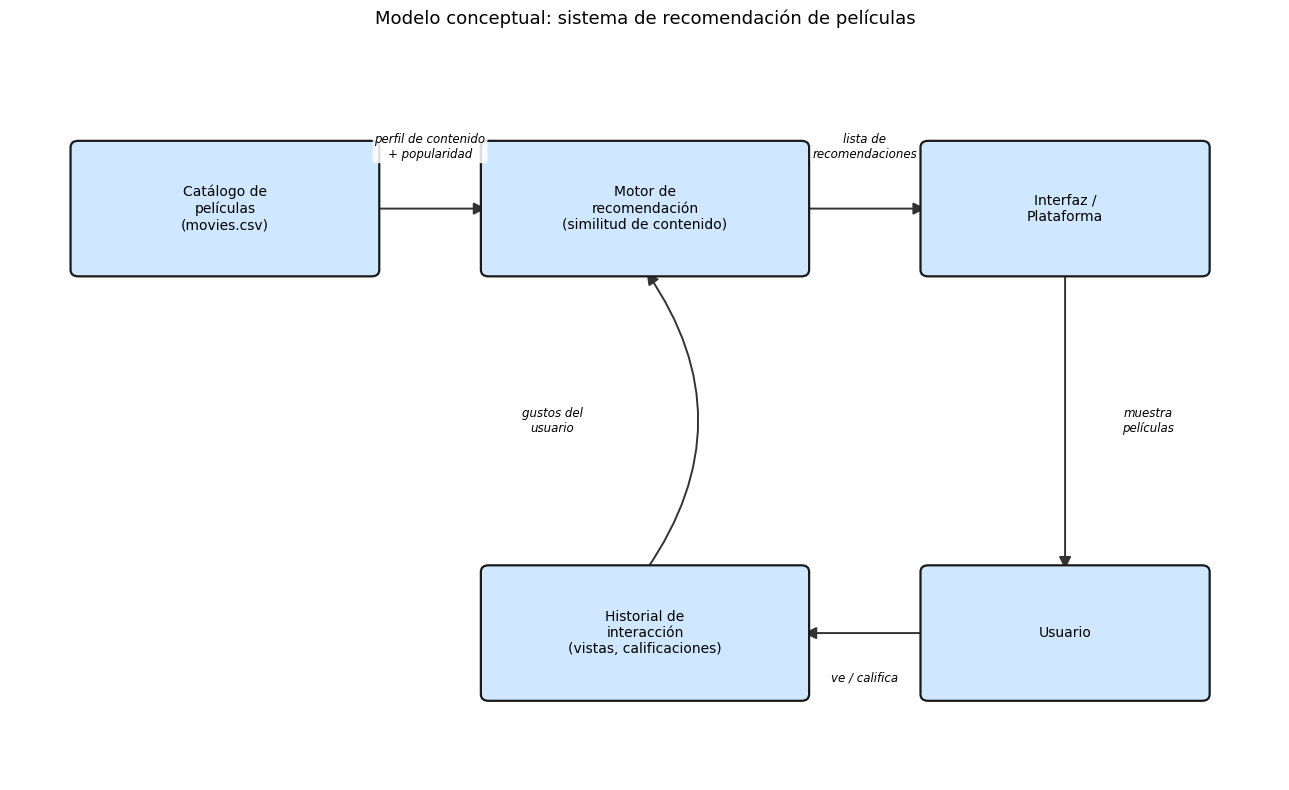

In [4]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import numpy as np

fig, ax = plt.subplots(figsize=(13, 8))
ax.set_xlim(0, 13)
ax.set_ylim(0, 9)
ax.axis("off")

# (centro_x, centro_y, ancho, alto, etiqueta)
boxes = {
    "catalogo":  (2.2, 7.0, 3.0, 1.5, "Catálogo de\npelículas\n(movies.csv)"),
    "motor":     (6.5, 7.0, 3.2, 1.5, "Motor de\nrecomendación\n(similitud de contenido)"),
    "interfaz":  (10.8, 7.0, 2.8, 1.5, "Interfaz /\nPlataforma"),
    "usuario":   (10.8, 1.8, 2.8, 1.5, "Usuario"),
    "historial": (6.5, 1.8, 3.2, 1.5, "Historial de\ninteracción\n(vistas, calificaciones)"),
}

for key, (cx, cy, w, h, label) in boxes.items():
    box = FancyBboxPatch((cx - w / 2, cy - h / 2), w, h,
                          boxstyle="round,pad=0.08", linewidth=1.6,
                          edgecolor="#1a1a1a", facecolor="#cfe8ff", zorder=2)
    ax.add_patch(box)
    ax.text(cx, cy, label, ha="center", va="center", fontsize=10, zorder=3)


def edge_point(cx, cy, w, h, tx, ty):
    """Punto donde la línea centro->objetivo cruza el borde del rectángulo,
    para que las flechas empiecen/terminen en el borde y no se encimen con el texto."""
    dx, dy = tx - cx, ty - cy
    if dx == 0 and dy == 0:
        return cx, cy
    scale_x = (w / 2) / abs(dx) if dx != 0 else np.inf
    scale_y = (h / 2) / abs(dy) if dy != 0 else np.inf
    scale = min(scale_x, scale_y)
    return cx + dx * scale, cy + dy * scale


def arrow(a, b, text="", rad=0.0, text_shift=(0, 0)):
    cxa, cya, wa, ha, _ = boxes[a]
    cxb, cyb, wb, hb, _ = boxes[b]
    pa = edge_point(cxa, cya, wa, ha, cxb, cyb)
    pb = edge_point(cxb, cyb, wb, hb, cxa, cya)
    arr = FancyArrowPatch(pa, pb, connectionstyle=f"arc3,rad={rad}",
                           arrowstyle="-|>", mutation_scale=18,
                           color="#333333", linewidth=1.4, zorder=1)
    ax.add_patch(arr)
    if text:
        mx, my = (pa[0] + pb[0]) / 2, (pa[1] + pb[1]) / 2
        ddx, ddy = pb[0] - pa[0], pb[1] - pa[1]
        mx += -ddy * rad * 0.5
        my += ddx * rad * 0.5
        mx += text_shift[0]
        my += text_shift[1]
        ax.text(mx, my, text, ha="center", va="center", fontsize=8.5, style="italic",
                 bbox=dict(boxstyle="round,pad=0.15", facecolor="white",
                           edgecolor="none", alpha=0.85), zorder=4)


arrow("catalogo", "motor", "perfil de contenido\n+ popularidad", text_shift=(0, 0.75))
arrow("motor", "interfaz", "lista de\nrecomendaciones", text_shift=(0, 0.75))
arrow("interfaz", "usuario", "muestra\npelículas", text_shift=(0.85, 0))
arrow("usuario", "historial", "ve / califica", text_shift=(0, -0.55))
arrow("historial", "motor", "gustos del\nusuario", rad=0.35, text_shift=(-0.3, 0))

ax.set_title("Modelo conceptual: sistema de recomendación de películas",
             fontsize=13, pad=15)
plt.tight_layout()
plt.show()

---

## 1.4. Ciclo de Vida de un Modelo

El ciclo de vida de un modelo son las etapas por las que pasa desde que se
plantea el problema hasta que el modelo queda en producción y se le da
mantenimiento:

1. **Definición del problema** — identificar qué debe resolver el modelo.
2. **Recopilación de datos** — obtener y preparar los datos necesarios.
3. **Diseño del modelo** — elegir el tipo de modelo y su estructura.
4. **Implementación** — construirlo con herramientas y técnicas adecuadas.
5. **Validación y prueba** — evaluar su precisión y eficacia.
6. **Despliegue** — ponerlo a funcionar en un entorno real.
7. **Mantenimiento y mejora** — actualizarlo con nuevos datos.

A continuación se recorre cada etapa aplicada al **modelo de recomendación de
películas**, implementándolo con los datos reales de `movies.csv`.

### 1. Definición del problema

Mejorar la experiencia del usuario recomendándole películas relevantes a
partir de las que ya vio o le gustaron, sin depender de un historial de
calificaciones de miles de usuarios (que no está disponible en este dataset).

### 2. Recopilación de datos

`movies.csv` ya funciona como la fuente de datos: 4803 películas con género,
reparto, director, palabras clave, sinopsis y métricas de popularidad. Antes
de diseñar el modelo, se revisan los datos disponibles y su calidad
(valores faltantes).

In [5]:
faltantes = df.isna().sum()
faltantes = faltantes[faltantes > 0].sort_values(ascending=False)
print("Valores faltantes por columna:")
faltantes

Valores faltantes por columna:


homepage        3091
tagline          844
keywords         412
cast              43
director          30
genres            28
overview           3
runtime            2
release_date       1
dtype: int64

In [6]:
# Preparación mínima: rellenar campos de texto vacíos para poder combinarlos
for col in ["genres", "keywords", "overview", "cast", "director"]:
    df[col] = df[col].fillna("")

# "Sopa de texto" con el perfil de contenido de cada película
df["perfil_contenido"] = (
    df["genres"] + " " + df["keywords"] + " " + df["cast"] + " " +
    df["director"] + " " + df["overview"]
)
df[["title", "perfil_contenido"]].head(3)

,title,perfil_contenido
0,Avatar,Action Adventure Fantasy Science Fiction cultu...
1,Pirates of the Caribbean: At World's End,Adventure Fantasy Action ocean drug abuse exot...
2,Spectre,Action Adventure Crime spy based on novel secr...


### 3. Diseño del modelo

Como `movies.csv` no tiene calificaciones individuales por usuario (solo un
promedio agregado `vote_average`), un **filtrado colaborativo** clásico no es
viable con esta fuente. En su lugar se diseña un **sistema de recomendación
basado en contenido**: se compara el texto que describe a cada película
(género, palabras clave, reparto, director, sinopsis) usando **TF-IDF** y
**similitud coseno**, y el resultado se puede ponderar con la popularidad
(`vote_average`, `vote_count`) para desempatar entre películas igualmente
similares.

### 4. Implementación

Se implementa en Python con `scikit-learn`: se vectoriza el `perfil_contenido`
con `TfidfVectorizer` y se calcula la similitud coseno entre todas las
películas.

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

tfidf = TfidfVectorizer(stop_words="english")
matriz_tfidf = tfidf.fit_transform(df["perfil_contenido"])
similitud = cosine_similarity(matriz_tfidf)

indice_por_titulo = pd.Series(df.index, index=df["title"]).drop_duplicates()

def recomendar(titulo, n=5):
    idx = indice_por_titulo[titulo]
    puntajes = list(enumerate(similitud[idx]))
    puntajes = sorted(puntajes, key=lambda x: x[1], reverse=True)
    puntajes = [p for p in puntajes if p[0] != idx][:n]
    indices = [p[0] for p in puntajes]
    resultado = df.loc[indices, ["title", "genres", "vote_average"]].copy()
    resultado["similitud"] = [round(p[1], 3) for p in puntajes]
    return resultado.reset_index(drop=True)

recomendar("Avatar")

,title,genres,vote_average,similitud
0,Lifeforce,Fantasy Horror Science Fiction Thriller,6.2,0.169
1,Star Trek Beyond,Action Adventure Science Fiction,6.6,0.158
2,Guardians of the Galaxy,Action Science Fiction Adventure,7.9,0.156
3,Gattaca,Thriller Science Fiction Mystery Romance,7.5,0.156
4,Moonraker,Action Adventure Thriller Science Fiction,5.9,0.152


In [8]:
recomendar("The Dark Knight Rises")

,title,genres,vote_average,similitud
0,The Dark Knight,Drama Action Crime Thriller,8.2,0.365
1,Batman Begins,Action Crime Drama,7.5,0.320
2,Batman Forever,Action Crime Fantasy,5.2,0.305
3,Batman Returns,Action Fantasy,6.6,0.284
4,Batman,Fantasy Action,7.0,0.251


### 5. Validación y prueba

No se cuenta con calificaciones por usuario para calcular RMSE, así que se usa
una métrica sencilla acorde a los datos disponibles: **cuántos géneros en
común** tienen las recomendaciones con la película consultada (un proxy de
precisión temática), además de revisar visualmente que las recomendaciones
tengan sentido.

In [9]:
def precision_por_genero(titulo, n=5):
    idx = indice_por_titulo[titulo]
    generos_base = set(df.loc[idx, "genres"].split())
    recomendadas = recomendar(titulo, n)
    aciertos = recomendadas["genres"].apply(
        lambda g: len(generos_base & set(g.split())) > 0
    )
    return aciertos.mean()

for peli in ["Avatar", "The Dark Knight Rises", "Toy Story"]:
    print(f"{peli}: {precision_por_genero(peli):.0%} de las recomendaciones comparten al menos un género")

Avatar: 100% de las recomendaciones comparten al menos un género
The Dark Knight Rises: 100% de las recomendaciones comparten al menos un género
Toy Story: 80% de las recomendaciones comparten al menos un género


**Limitaciones observadas:** el modelo es sensible a la calidad del texto
(sinopsis muy cortas o `keywords` vacíos degradan la similitud), y al ser
puramente de contenido, tiende a recomendar "más de lo mismo" en vez de
sorprender al usuario (poca serendipia). Combinarlo con la popularidad
(`vote_average`, `vote_count`) ayuda a filtrar sugerencias de baja calidad.

### 6. Despliegue

En un entorno real, `recomendar()` se expondría como un endpoint del backend
de la plataforma (por ejemplo una API REST). Al abrir una ficha de película o
terminar de verla, la interfaz llamaría a ese endpoint para mostrar la
sección "Películas similares" en tiempo real.

### 7. Mantenimiento y mejora

El catálogo (`movies.csv`) se actualizaría periódicamente con estrenos nuevos
y con métricas de popularidad más recientes. Como mejora futura, en cuanto se
acumule historial real de usuarios, se podría combinar este modelo de
contenido con un filtrado colaborativo (un enfoque híbrido), que sí aprovecha
qué tan parecidos son los gustos entre usuarios.